# NexTwin AI — Industrial Digital Twin Platform
## Notebook 01: Exploratory Data Analysis & Industrial Insights

### Vision
This notebook loads, inspects, and analyzes all the raw datasets for our Industrial Digital Twin platform. We explore schemas, statistics, missing values, and sensor correlation networks to extract actionable industrial insights.

### Objectives
1. **Load all datasets**: AI4I Predictive Maintenance, NASA Turbofan (C-MAPSS), Energy Consumption, Machine Utilization, Production Metrics, and Synthetic Factory Data.
2. **Schema & Statistical Analysis**: Understand variables, types, ranges, and basic summary metrics.
3. **Missing Value & Data Integrity Review**: Report null rates and check for duplicate values.
4. **Visual Explorations**: Plot feature distributions, sensor correlations, failure distributions, and operational trends.
5. **Industrial Insights**: Document key patterns and engineering implications.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configure visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading & Verification
We verify that the raw data folder exists and load each dataset. If any of the synthetic CSV files are empty, we invoke the `generate_synthetic_data` module to populate them.

In [2]:
# Check if synthetic data needs generation
util_file = os.path.join("..", "datasets", "raw", "machine_utilization.csv")
if not os.path.exists(util_file) or os.path.getsize(util_file) == 0:
    print("Synthetic files are empty or missing. Running generate_synthetic_data.py...")
    import subprocess
    subprocess.run(["python", "generate_synthetic_data.py"], check=True)

# Paths definition
BASE_PATH = os.path.join("..", "datasets", "raw")
PM_PATH = os.path.join(BASE_PATH, "ai4i_predictive_maintenance.csv")
NASA_DIR = os.path.join(BASE_PATH, "nasa_turbofan")
ENERGY_PATH = os.path.join(BASE_PATH, "energy_consumption.csv")
UTIL_PATH = os.path.join(BASE_PATH, "machine_utilization.csv")
PROD_PATH = os.path.join(BASE_PATH, "production_metrics.csv")
FACTORY_PATH = os.path.join(BASE_PATH, "machine_sounds", "synthetic_factory_data.csv")

# Loading datasets
print("Loading datasets...")
df_pm = pd.read_csv(PM_PATH)
df_energy = pd.read_excel(ENERGY_PATH)
df_util = pd.read_csv(UTIL_PATH)
df_prod = pd.read_csv(PROD_PATH)
df_factory = pd.read_csv(FACTORY_PATH)

# NASA Turbofan (FD001 as reference)
nasa_cols = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f'sensor_{i}' for i in range(1, 22)]
df_nasa_train = pd.read_csv(os.path.join(NASA_DIR, "train_FD001.txt"), sep=r"\s+", header=None, names=nasa_cols)
df_nasa_test = pd.read_csv(os.path.join(NASA_DIR, "test_FD001.txt"), sep=r"\s+", header=None, names=nasa_cols)
df_nasa_rul = pd.read_csv(os.path.join(NASA_DIR, "RUL_FD001.txt"), sep=r"\s+", header=None, names=['RUL'])

print("All datasets loaded successfully.")

Loading datasets...


All datasets loaded successfully.


## 2. Schema and Dimensionality Analysis
Let's review the dimensions and column schemas of each dataset in our digital twin architecture.

In [3]:
datasets = {
    "Predictive Maintenance (AI4I)": df_pm,
    "NASA Turbofan FD001 (Train)": df_nasa_train,
    "Energy Consumption": df_energy,
    "Machine Utilization": df_util,
    "Production Metrics": df_prod,
    "Synthetic Factory Data (Acoustic)": df_factory
}

for name, df in datasets.items():
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Types: {df.dtypes.to_dict()}")
    print("-" * 50)

=== Predictive Maintenance (AI4I) ===
Shape: (10000, 14)
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Types: {'UDI': dtype('int64'), 'Product ID': dtype('O'), 'Type': dtype('O'), 'Air temperature [K]': dtype('float64'), 'Process temperature [K]': dtype('float64'), 'Rotational speed [rpm]': dtype('int64'), 'Torque [Nm]': dtype('float64'), 'Tool wear [min]': dtype('int64'), 'Machine failure': dtype('int64'), 'TWF': dtype('int64'), 'HDF': dtype('int64'), 'PWF': dtype('int64'), 'OSF': dtype('int64'), 'RNF': dtype('int64')}
--------------------------------------------------
=== NASA Turbofan FD001 (Train) ===
Shape: (20631, 26)
Columns: ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_

## 3. Data Integrity & Missing Values Report
We inspect each dataset for missing values and duplicates to build an integrity report.

In [4]:
for name, df in datasets.items():
    nulls = df.isnull().sum()
    null_pct = (nulls / len(df)) * 100
    duplicates = df.duplicated().sum()
    
    print(f"=== Data Integrity Report: {name} ===")
    print(f"Duplicate Rows: {duplicates}")
    null_df = pd.DataFrame({'Null Count': nulls, 'Null Percentage': null_pct})
    null_df = null_df[null_df['Null Count'] > 0]
    if len(null_df) > 0:
        print("Columns with missing values:")
        print(null_df)
    else:
        print("No missing values found.")
    print("-" * 50)

=== Data Integrity Report: Predictive Maintenance (AI4I) ===
Duplicate Rows: 0
No missing values found.
--------------------------------------------------
=== Data Integrity Report: NASA Turbofan FD001 (Train) ===
Duplicate Rows: 0
No missing values found.
--------------------------------------------------
=== Data Integrity Report: Energy Consumption ===
Duplicate Rows: 0
No missing values found.
--------------------------------------------------
=== Data Integrity Report: Machine Utilization ===
Duplicate Rows: 0
No missing values found.
--------------------------------------------------
=== Data Integrity Report: Production Metrics ===
Duplicate Rows: 0
No missing values found.
--------------------------------------------------
=== Data Integrity Report: Synthetic Factory Data (Acoustic) ===
Duplicate Rows: 0
No missing values found.
--------------------------------------------------


## 4. Statistical Summary
Let's examine the distributions, ranges, and standard deviations of the datasets.

In [5]:
print("AI4I Predictive Maintenance Descriptive Stats:")
display(df_pm.describe())

print("\nEnergy Efficiency (UCI) Descriptive Stats:")
display(df_energy.describe())

print("\nSynthetic Factory Data (Acoustic) Descriptive Stats:")
display(df_factory.describe())

AI4I Predictive Maintenance Descriptive Stats:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



Energy Efficiency (UCI) Descriptive Stats:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000



Synthetic Factory Data (Acoustic) Descriptive Stats:


,vibration_mm_s,temperature_c,pressure_bar,noise_level_db,sound_frequency_hz,sound_amplitude,anomaly_label
count,6483.000000,6483.000000,6483.000000,6483.000000,6483.000000,6483.000000,6483.000000
mean,1.832742,60.118839,4.196482,72.203440,519.768255,0.060675,0.008329
std,0.496504,4.834261,0.500090,2.717246,46.482006,0.018910,0.090892
min,0.431000,45.420000,2.500000,64.600000,353.500000,0.008300,0.000000
25%,1.549000,56.620000,3.860000,70.700000,489.000000,0.049500,0.000000
50%,1.807000,60.010000,4.200000,72.000000,519.900000,0.059500,0.000000
75%,2.073500,63.570000,4.530000,73.400000,551.000000,0.070200,0.000000
max,6.318000,84.380000,6.020000,98.200000,693.800000,0.231700,1.000000


## 5. Exploratory Visualizations
Let's visualize distributions, target distributions, correlations, and relationships.

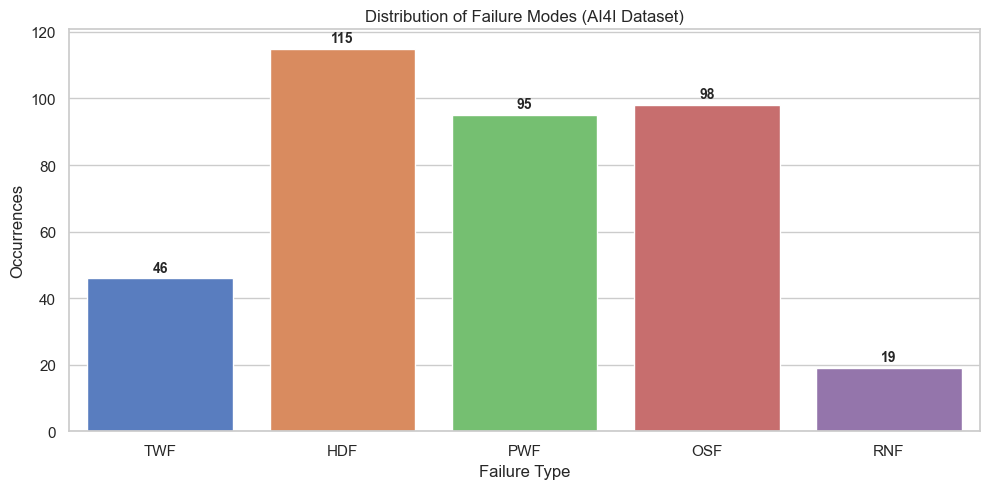

In [6]:
# Machine Failure and Modes in AI4I
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df_pm[failure_modes].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=failure_counts.index, y=failure_counts.values, hue=failure_counts.index, legend=False)
plt.title('Distribution of Failure Modes (AI4I Dataset)')
plt.ylabel('Occurrences')
plt.xlabel('Failure Type')
for idx, val in enumerate(failure_counts.values):
    plt.text(idx, val + 2, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

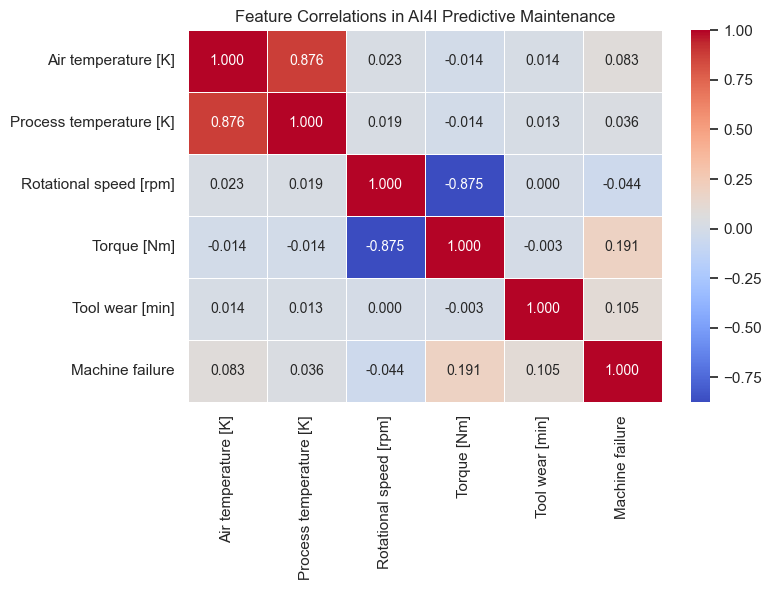

In [7]:
# Correlation Matrix for AI4I continuous features
num_cols_pm = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
corr_pm = df_pm[num_cols_pm].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_pm, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Feature Correlations in AI4I Predictive Maintenance')
plt.tight_layout()
plt.show()

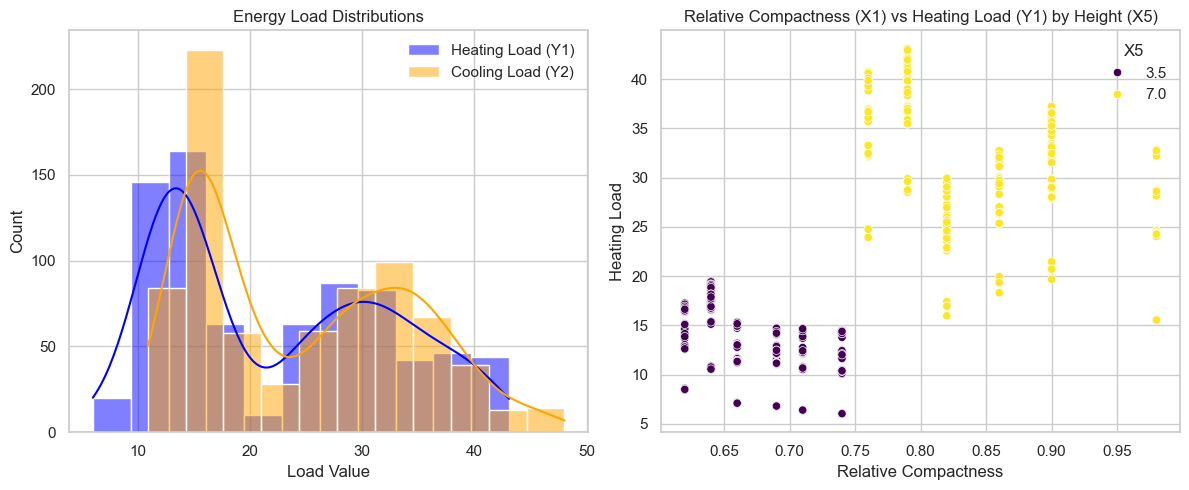

In [8]:
# Energy Consumption distributions and correlations
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_energy['Y1'], kde=True, color='blue', label='Heating Load (Y1)')
sns.histplot(df_energy['Y2'], kde=True, color='orange', label='Cooling Load (Y2)')
plt.title('Energy Load Distributions')
plt.xlabel('Load Value')
plt.legend()

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_energy, x='X1', y='Y1', hue='X5', palette='viridis')
plt.title('Relative Compactness (X1) vs Heating Load (Y1) by Height (X5)')
plt.xlabel('Relative Compactness')
plt.ylabel('Heating Load')

plt.tight_layout()
plt.show()

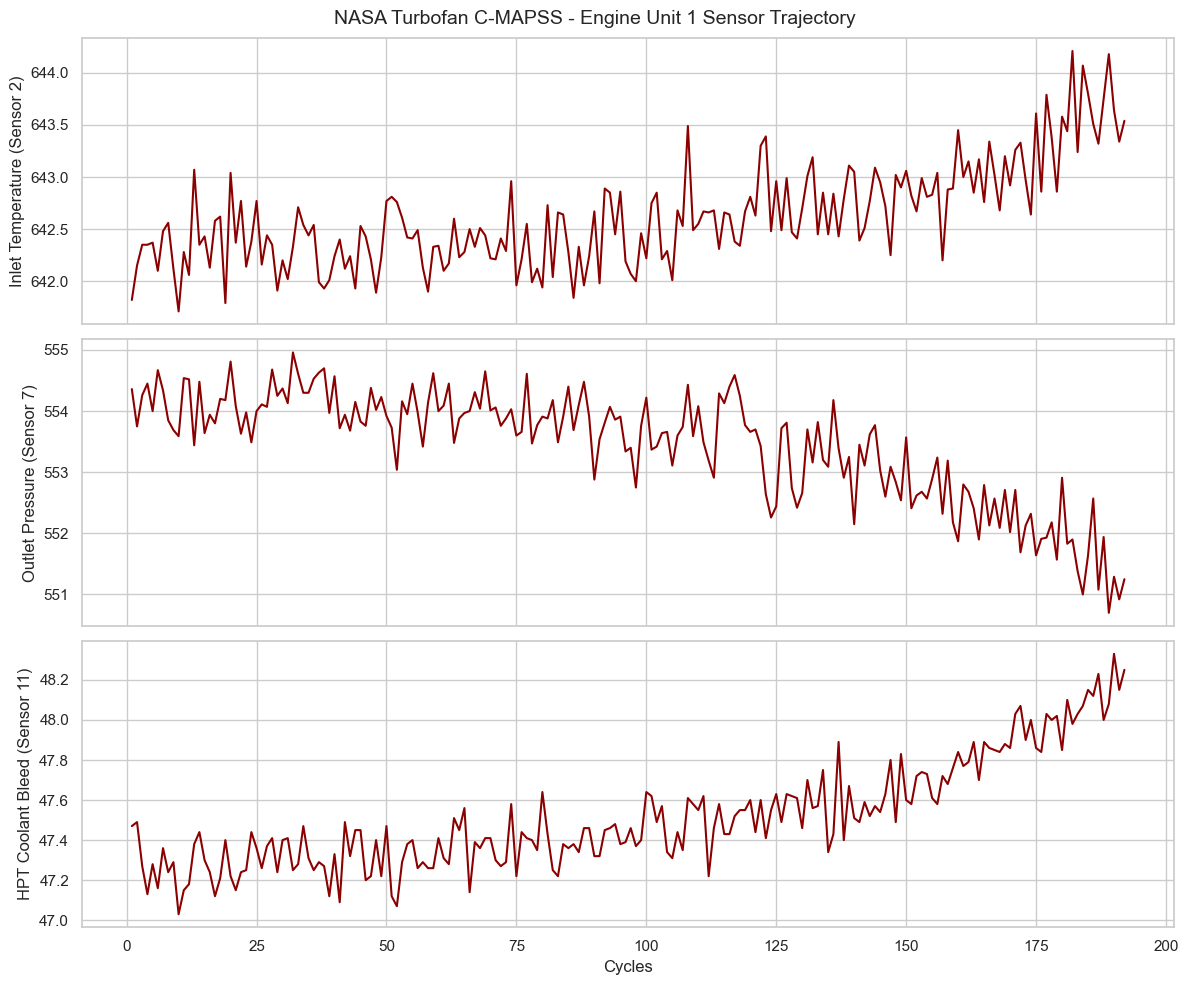

In [9]:
# Plot sample engine trajectories from NASA Turbofan
sample_unit = 1
df_unit = df_nasa_train[df_nasa_train['unit_number'] == sample_unit]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
sensors_to_plot = ['sensor_2', 'sensor_7', 'sensor_11']
sensor_labels = ['Inlet Temperature (Sensor 2)', 'Outlet Pressure (Sensor 7)', 'HPT Coolant Bleed (Sensor 11)']

for idx, sensor in enumerate(sensors_to_plot):
    axes[idx].plot(df_unit['time_in_cycles'], df_unit[sensor], color='darkred', lw=1.5)
    axes[idx].set_ylabel(sensor_labels[idx])
    axes[idx].grid(True)

axes[2].set_xlabel('Cycles')
plt.suptitle(f'NASA Turbofan C-MAPSS - Engine Unit {sample_unit} Sensor Trajectory', y=0.98, fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Plot Interactive Sound Frequency vs Noise Level with Plotly
df_sample_fac = df_factory.sample(1000, random_state=42)
fig = px.scatter(
    df_sample_fac,
    x="noise_level_db",
    y="sound_frequency_hz",
    color="anomaly_label",
    symbol="machine_id",
    title="Factory Acoustic Anomaly Exploration (Sampled)",
    labels={
        "noise_level_db": "Noise Level (dB)",
        "sound_frequency_hz": "Dominant Frequency (Hz)",
        "anomaly_label": "Anomaly Indicator"
    },
    color_continuous_scale=["teal", "crimson"]
)
fig.update_layout(template="plotly_white")
fig.show()

## 6. Industrial Insights Summary

From our Exploratory Data Analysis, we extract several critical takeaways for the NexTwin AI Industrial Digital Twin system:

1. **Predictive Maintenance (AI4I)**:
   - Total machine failures occur in ~3.39% of the dataset (339/10000 records). This indicates class imbalance, requiring appropriate handling during modeling (e.g. class weights, SMOTE, or recall-oriented thresholds).
   - There is a high correlation between `Torque [Nm]` and `Rotational speed [rpm]` (strong negative correlation, as torque increases, rotational speed drops). This physical relationship is standard in electric motors and can be exploited for feature engineering.

2. **NASA Turbofan Degradation (C-MAPSS)**:
   - Certain sensors (e.g., `sensor_2`, `sensor_7`, `sensor_11`) show clear trending behavior as the engine approaches its maximum operational cycles, representing useful life consumption. Sensor variance also tends to increase closer to failure, pointing to the value of rolling standard deviation features.

3. **Energy Optimization**:
   - In the energy dataset, building height (`X5`) splits the dataset into distinct energy profiles. Taller buildings (height = 7) show substantially higher heating (`Y1`) and cooling (`Y2`) loads, and their efficiency behavior changes based on compactness (`X1`).

4. **Acoustic Sensor Anomalies**:
   - Machine sound frequency and amplitude show visual clustering under normal operations. Anomalies are characterized by elevated noise levels (>90 dB) and sudden shifts in dominant frequency, indicating mechanical friction or component breakage.